# Student Performance Analysis

This notebook analyzes student performance using Python, Pandas and data visualization.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print('Libraries imported successfully')

Libraries imported successfully


In [5]:
# Load the CSV file from the data folder
data_folder = 'data'
csv_files = [f for f in os.listdir(data_folder) if f.lower().endswith('.csv')]

if not csv_files:
    raise FileNotFoundError('No CSV file found in the data folder.')

file_path = os.path.join(data_folder, csv_files[0])
df = pd.read_csv(file_path)

print('Loaded file:', csv_files[0])
df.head()

Loaded file: student_performance.csv


,student_id,gender,study_hours,attendance,math_score,science_score,english_score
0,1,Female,2,85,78,82,80
1,2,Male,4,92,88,90,85
2,3,Female,3,88,84,86,89
3,4,Male,1,70,65,68,72
4,5,Female,5,95,92,94,91


In [6]:
# Basic information
print('Shape:', df.shape)
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)


Shape: (15, 7)

Columns:
['student_id', 'gender', 'study_hours', 'attendance', 'math_score', 'science_score', 'english_score']

Data types:
student_id       int64
gender             str
study_hours      int64
attendance       int64
math_score       int64
science_score    int64
english_score    int64
dtype: object


In [7]:
# Check missing values and duplicate rows
print('Missing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

Missing values:
student_id       0
gender           0
study_hours      0
attendance       0
math_score       0
science_score    0
english_score    0
dtype: int64

Duplicate rows: 0


In [8]:
# Summary statistics for numeric columns
df.describe(include='all')

,student_id,gender,study_hours,attendance,math_score,science_score,english_score
count,15.000000,15,15.000000,15.000000,15.000000,15.000000,15.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN,NaN,NaN
freq,NaN,8,NaN,NaN,NaN,NaN,NaN
mean,8.000000,NaN,3.333333,85.800000,82.533333,83.266667,84.066667
std,4.472136,NaN,1.543033,9.397568,10.098562,9.587691,9.114092
min,1.000000,NaN,1.000000,68.000000,64.000000,66.000000,70.000000
25%,4.500000,NaN,2.000000,80.000000,76.000000,77.000000,77.000000
50%,8.000000,NaN,3.000000,88.000000,85.000000,86.000000,86.000000
75%,11.500000,NaN,4.500000,93.000000,90.000000,90.500000,90.500000


In [9]:
# Correlation between numeric variables
numeric_df = df.select_dtypes(include='number')

if numeric_df.shape[1] >= 2:
    print(numeric_df.corr())
else:
    print('Not enough numeric columns for correlation analysis.')

               student_id  study_hours  attendance  math_score  science_score  \
student_id       1.000000     0.238073    0.056086    0.136018      -0.013327   
study_hours      0.238073     1.000000    0.945763    0.964151       0.906087   
attendance       0.056086     0.945763    1.000000    0.990948       0.979694   
math_score       0.136018     0.964151    0.990948    1.000000       0.975183   
science_score   -0.013327     0.906087    0.979694    0.975183       1.000000   
english_score    0.169987     0.917617    0.938367    0.953372       0.932457   

               english_score  
student_id          0.169987  
study_hours         0.917617  
attendance          0.938367  
math_score          0.953372  
science_score       0.932457  
english_score       1.000000  


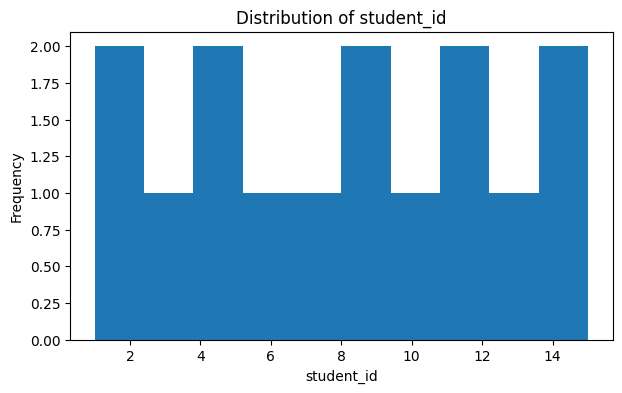

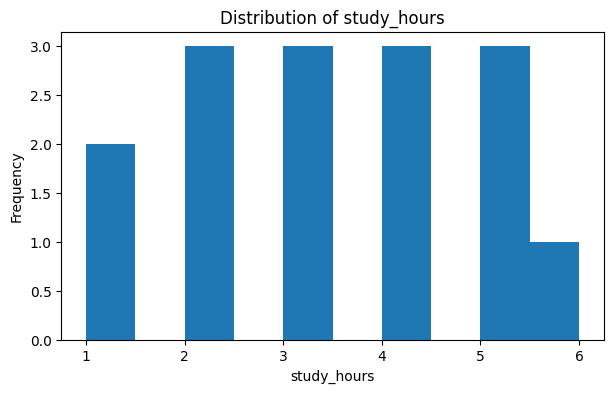

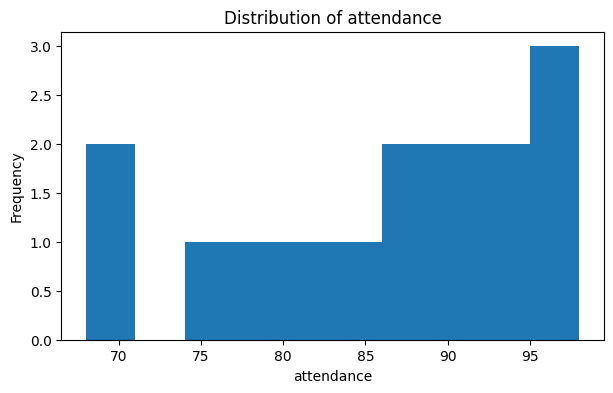

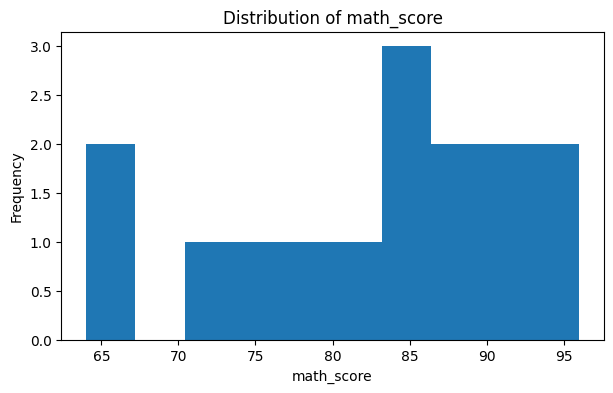

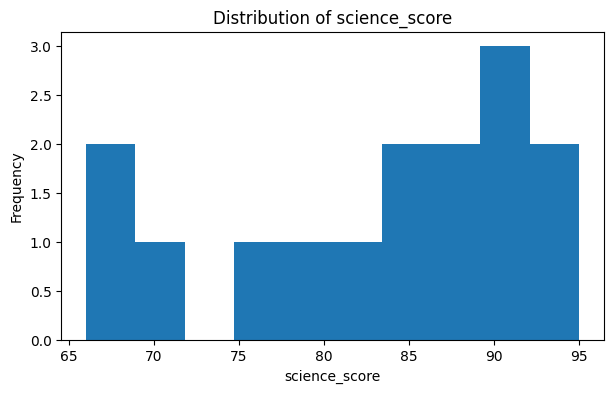

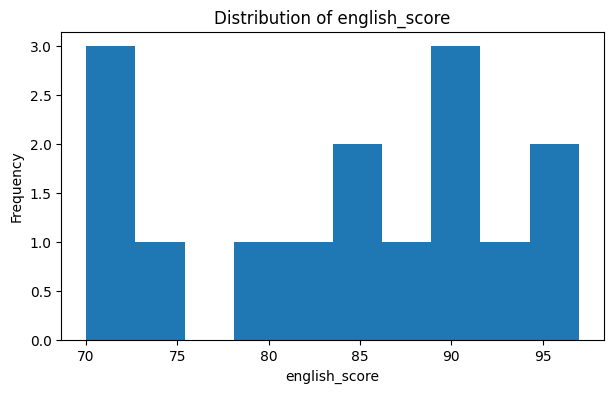

In [10]:
# Histograms for numeric columns
numeric_columns = df.select_dtypes(include='number').columns

for column in numeric_columns:
    plt.figure(figsize=(7, 4))
    plt.hist(df[column].dropna(), bins=10)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

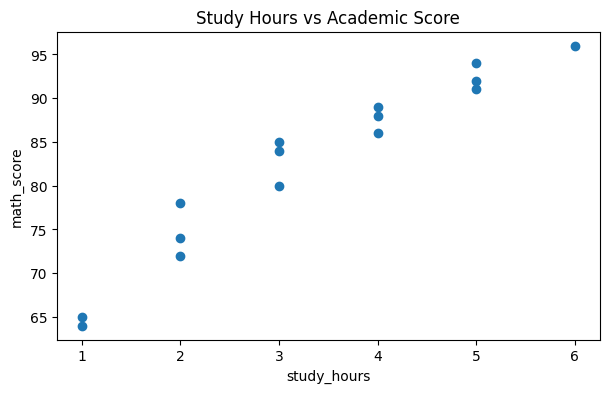

In [11]:
# Try to identify study-hours and score columns for a simple relationship plot
study_col = next((c for c in df.columns if 'study' in c.lower() and 'hour' in c.lower()), None)
score_col = next((c for c in df.columns if 'score' in c.lower() or 'mark' in c.lower() or 'grade' in c.lower()), None)

if study_col and score_col:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[study_col], df[score_col])
    plt.title('Study Hours vs Academic Score')
    plt.xlabel(study_col)
    plt.ylabel(score_col)
    plt.show()
else:
    print('Study-hours and score columns were not automatically identified.')

## Conclusion

The analysis helps understand student performance, data quality, numerical patterns, and relationships between study-related factors and academic scores.